# 2. Feature Selection

**Purpose:** Determine which summary statistics to retain

**Approach:**
1. Build full feature matrix, audit NaN rates
2. Pooled Spearman correlation → clustered heatmap → redundant groups
3. Within-animal Spearman correlation (removes between-animal variance)
4. PCA — effective dimensionality
5. Early vs Late Wilcoxon — which features significantly change with learning?
6. Select representative features

In [ ]:
%matplotlib inline

import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from behav_utils.data.structures import ExperimentData, AnimalData
from behav_utils.data.synthetic import generate_synthetic_animal
from behav_utils.data.loading import load_experiment, load_from_directory
from behav_utils.analysis.session_features import (
    build_feature_matrix,
    build_feature_matrix_multi,
    get_feature_columns,
    METADATA_COLUMNS,
    summarise_features,
)
from behav_utils.analysis.summary_stats import FEATURE_MATRIX_STATS

print("Imports OK")
print(f"FEATURE_MATRIX_STATS ({len(FEATURE_MATRIX_STATS)}):")
for s in FEATURE_MATRIX_STATS:
    print(f"  - {s}")

Imports OK
FEATURE_MATRIX_STATS (21):
  - accuracy
  - psychometric
  - psychometric_gof
  - recency
  - stimulus_recency
  - recency_divergence
  - win_stay
  - lose_shift
  - stimulus_sensitivity
  - side_bias
  - choice_autocorr
  - choice_entropy
  - perseveration
  - hard_easy_ratio
  - hard_accuracy
  - easy_accuracy
  - history_interaction_r2
  - sd_profile
  - logistic_history
  - update_matrix
  - conditional_psychometric


---
## 1. Load Data

Three options — uncomment the one you need.

**Option A:** `load_experiment('config.yaml')` — reads CSVs from disk using your config.  
**Option B:** `ExperimentData.load('experiment.pkl')` — reload from a saved pickle.  
**Option C:** Generate synthetic data (default for pipeline testing).

### Option A
`load_experiment('config.yaml')` — reads CSVs from disk using your config.  


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION A: Load from CSV files
# ═══════════════════════════════════════════════════════════════════════════

# path_config = 'path/to/config.yaml'
# experiment = load_experiment(path_config)
# STAGE = 'Full_Task_Cont'
# SHIFT_SESSION = None

# # Or point directly at a data directory:
# data_path = ''
# experiment = load_from_directory(data_path, config_path=path_config)

# # Load a single animal:
# from behav_utils.data.loading import load_animal
# from behav_utils.config.schema import load_config
# config = load_config(config_path)
# animal_path = ''
# animal = load_animal(animal_path, config)


### Option B
`ExperimentData.load('experiment.pkl')` — reload from a saved pickle.  


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION B: Load from saved pickle
# ═══════════════════════════════════════════════════════════════════════════
# experiment = ExperimentData.load('experiment.pkl')
# animal = AnimalData.load('SS05.pkl')

### Option C
Generate synthetic data (default for pipeline testing).

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# OPTION C: Generate synthetic data (default)
# ═══════════════════════════════════════════════════════════════════════════
USE_SYNTHETIC = True

if USE_SYNTHETIC:
    def _learning_simulator(stimuli, categories, rng, sigma=0.3, lapse=0.05, **kw):
        from scipy.stats import norm
        p_b = lapse + (1 - 2 * lapse) * norm.cdf(stimuli, 0, sigma)
        return (rng.random(len(stimuli)) < p_b).astype(float)

    def generate_cohort(n_animals=5, n_sessions=25, shift_session=15, seed=42):
        rng = np.random.default_rng(seed)
        experiment = ExperimentData(metadata={'cohort': 'synthetic_demo'})
        for a in range(n_animals):
            animal_id = f'SYN{a+1:02d}'
            animal_seed = int(rng.integers(0, 2**31))
            rate = 0.1 + rng.uniform(-0.03, 0.03)
            sigmas = [max(0.12, 0.6 * np.exp(-rate * s)) for s in range(n_sessions)]
            lapses = [max(0.02, 0.15 * np.exp(-0.12 * s)) for s in range(n_sessions)]
            per_session_kwargs = [{'sigma': sigmas[s], 'lapse': lapses[s]}
                                  for s in range(n_sessions)]
            dist_schedule = (['uniform'] * shift_session
                             + ['exponential_left'] * (n_sessions - shift_session))
            animal, _ = generate_synthetic_animal(
                animal_id=animal_id, n_sessions=n_sessions, trials_per_session=300,
                seed=animal_seed, simulator=_learning_simulator,
                per_session_simulator_kwargs=per_session_kwargs,
                distribution_schedule=dist_schedule, stage='Full_Task_Cont',
            )
            experiment.add_animal(animal)
        return experiment

    experiment = generate_cohort()
    SHIFT_SESSION = 15
    STAGE = 'Full_Task_Cont'
    print(f"Generated synthetic cohort: {experiment.n_animals} animals, {experiment.animal_ids}")
else:
    SHIFT_SESSION = None
    STAGE = 'Full_Task_Cont'
    print(f"Loaded: {experiment.n_animals} animals, {experiment.animal_ids}")

Generated synthetic cohort: 5 animals, ['SYN01', 'SYN02', 'SYN03', 'SYN04', 'SYN05']


---
## 2. Build Full Feature Matrix

In [5]:
all_animals = experiment.get_animals(min_sessions=5)
pooled_df = build_feature_matrix_multi(all_animals, stage=STAGE)
print(f"Feature matrix: {pooled_df.shape[0]} sessions × {pooled_df.shape[1]} columns")
print(f"Animals: {pooled_df['animal_id'].nunique()}")
print(f"Sessions per animal: {pooled_df.groupby('animal_id').size().values}")

Feature matrix: 125 sessions × 151 columns
Animals: 5
Sessions per animal: [25 25 25 25 25]


## 3. NaN Audit & Feature Filtering

In [6]:
feature_cols = get_feature_columns(pooled_df)
print(f"Numeric feature columns: {len(feature_cols)}")

nan_counts = pooled_df[feature_cols].isna().sum().sort_values(ascending=False)
nan_pct = (nan_counts / len(pooled_df) * 100).round(1)
nan_df = pd.DataFrame({'feature': nan_counts.index, 'n_nan': nan_counts.values,
                        'pct_nan': nan_pct.values})

print("\nNaN prevalence:")
print(nan_df[nan_df['n_nan'] > 0].to_string(index=False))
if nan_df['n_nan'].sum() == 0:
    print("  (all features fully populated)")

NAN_THRESHOLD = 0.20
high_nan = nan_df[nan_df['pct_nan'] > NAN_THRESHOLD * 100]['feature'].tolist()
if high_nan:
    print(f"\nExcluding (>{NAN_THRESHOLD*100:.0f}% NaN): {high_nan}")

clean_features = [f for f in feature_cols if f not in high_nan]

# Also remove near-zero-variance
variances = pooled_df[clean_features].var()
near_zero = variances[variances < 1e-10].index.tolist()
if near_zero:
    print(f"Removing near-zero-variance: {near_zero}")
    clean_features = [f for f in clean_features if f not in near_zero]

print(f"\nRetained features: {len(clean_features)}")

Numeric feature columns: 134

NaN prevalence:
Empty DataFrame
Columns: [feature, n_nan, pct_nan]
Index: []
  (all features fully populated)
Removing near-zero-variance: ['recency_divergence']

Retained features: 133


In [7]:
feat_summary = pooled_df[clean_features].describe().T
feat_summary['cv'] = (feat_summary['std'] / feat_summary['mean'].abs()).round(3)
print("Feature distributions:")
print(feat_summary[['count', 'mean', 'std', 'min', '50%', 'max', 'cv']].round(4).to_string())

Feature distributions:
                        count      mean      std       min       50%       max        cv
accuracy                125.0    0.8516   0.0717    0.6246    0.8780    0.9446     0.084
pse                     125.0    0.0097   0.0896   -0.3541   -0.0000    0.5858     9.228
slope                   125.0    0.2348   0.1740    0.0399    0.1706    1.0576     0.741
lapse_low               125.0    0.0518   0.0569    0.0000    0.0355    0.2829     1.099
lapse_high              125.0    0.0493   0.0547    0.0000    0.0324    0.2784     1.110
psychometric_gof        125.0    0.9829   0.0210    0.8826    0.9895    0.9988     0.021
recency                 125.0   -0.0018   0.0596   -0.1568   -0.0010    0.1278    32.428
stimulus_recency        125.0   -0.0018   0.0596   -0.1568   -0.0010    0.1278    32.428
win_stay                125.0    0.0036   0.0906   -0.2468   -0.0054    0.1996    25.432
lose_shift              125.0    0.5050   0.0868    0.2292    0.5000    0.6957     0.17

---
## 4. Pooled Spearman Correlation

Pairwise Spearman across all sessions (pooled). Clusters features by similarity.

In [8]:
corr_df = pooled_df[clean_features].dropna()
print(f"Complete cases: {len(corr_df)} / {len(pooled_df)}")

corr_matrix, _ = spearmanr(corr_df)
corr_matrix = pd.DataFrame(corr_matrix, index=clean_features, columns=clean_features).fillna(0)

dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)
dist_matrix = np.clip((dist_matrix + dist_matrix.T) / 2, 0, None)
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

Complete cases: 125 / 125


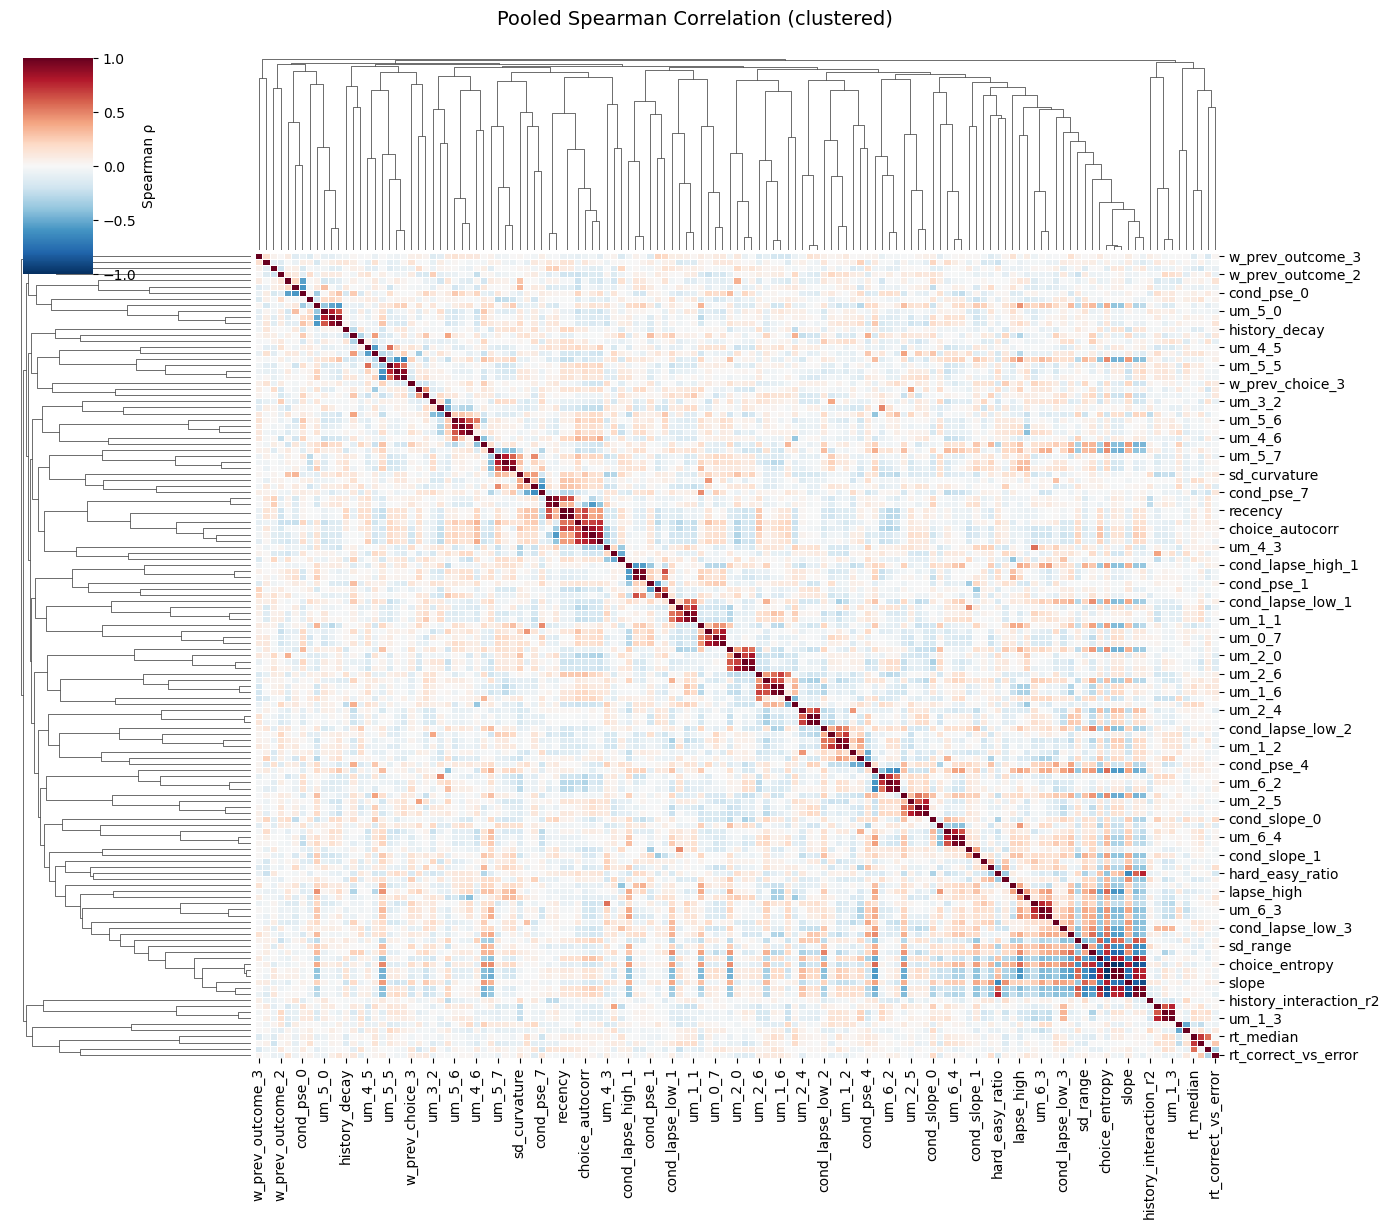

In [9]:
g = sns.clustermap(
    corr_matrix, row_linkage=Z, col_linkage=Z,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    figsize=(14, 12), linewidths=0.5, annot=False,
    cbar_kws={'label': 'Spearman ρ'},
)
g.fig.suptitle('Pooled Spearman Correlation (clustered)', y=1.02, fontsize=14)
plt.show()

In [10]:
CORR_THRESHOLD = 0.70
clusters = fcluster(Z, t=1 - CORR_THRESHOLD, criterion='distance')
cluster_df = pd.DataFrame({'feature': clean_features, 'cluster': clusters}).sort_values('cluster')

print(f"Clusters (|ρ| > {CORR_THRESHOLD}): {cluster_df['cluster'].nunique()}\n")
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['feature'].tolist()
    if len(members) > 1:
        sub = corr_matrix.loc[members, members]
        triu = sub.values[np.triu_indices(len(members), k=1)]
        print(f"Cluster {c} (n={len(members)}, mean |ρ|={np.mean(np.abs(triu)):.2f}):")
    else:
        print(f"Cluster {c} (singleton):")
    for m in members:
        print(f"  - {m}")
    print()

Clusters (|ρ| > 0.7): 99

Cluster 1 (singleton):
  - w_prev_outcome_3

Cluster 2 (singleton):
  - rt_iqr

Cluster 3 (singleton):
  - w_prev_outcome_1

Cluster 4 (singleton):
  - w_prev_outcome_2

Cluster 5 (singleton):
  - um_4_0

Cluster 6 (singleton):
  - cond_pse_0

Cluster 7 (singleton):
  - um_3_0

Cluster 8 (n=3, mean |ρ|=0.77):
  - um_5_0
  - um_6_0
  - um_7_0

Cluster 9 (singleton):
  - cond_lapse_high_0

Cluster 10 (singleton):
  - w_prev_choice_2

Cluster 11 (singleton):
  - pse

Cluster 12 (singleton):
  - side_bias

Cluster 13 (singleton):
  - history_decay

Cluster 14 (singleton):
  - um_4_5

Cluster 15 (singleton):
  - cond_pse_5

Cluster 16 (n=2, mean |ρ|=0.90):
  - um_7_5
  - um_6_5

Cluster 17 (singleton):
  - um_5_5

Cluster 18 (singleton):
  - cond_lapse_high_5

Cluster 19 (singleton):
  - um_3_5

Cluster 20 (singleton):
  - cond_slope_5

Cluster 21 (singleton):
  - w_prev_choice_3

Cluster 22 (singleton):
  - um_4_2

Cluster 23 (singleton):
  - cond_pse_2

Cluster 2

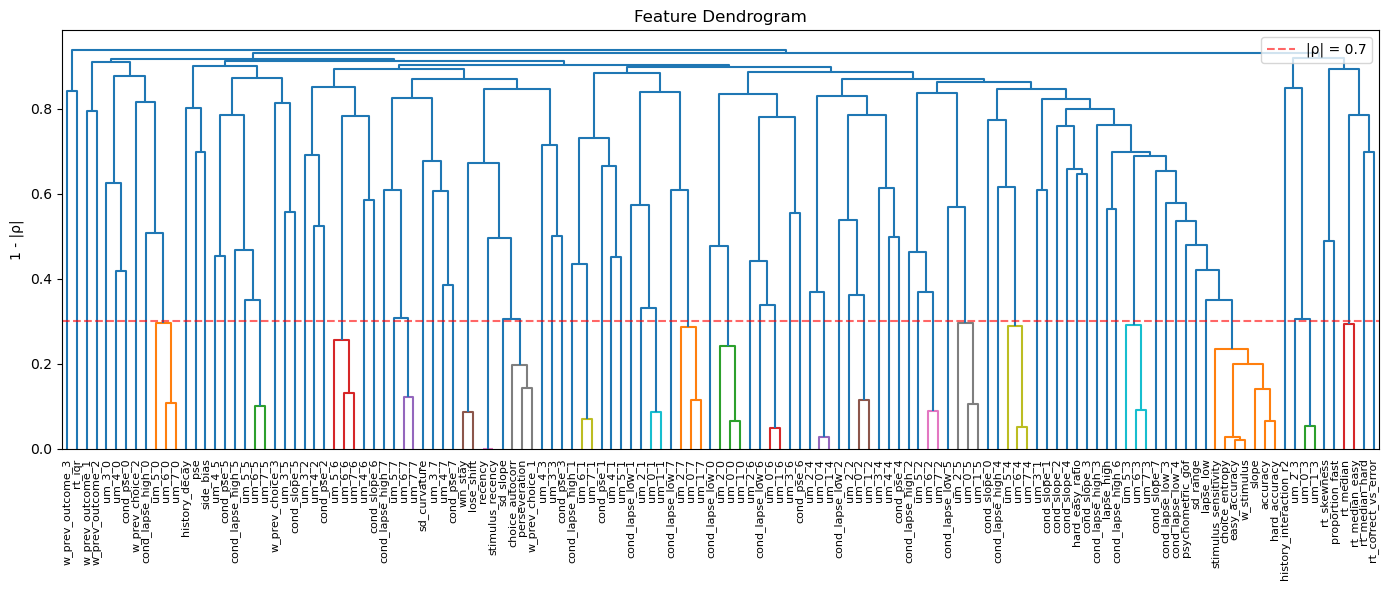

In [11]:
# Dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=clean_features, leaf_rotation=90, leaf_font_size=8,
           ax=ax, color_threshold=1 - CORR_THRESHOLD)
ax.axhline(1 - CORR_THRESHOLD, color='red', linestyle='--', alpha=0.6,
           label=f'|ρ| = {CORR_THRESHOLD}')
ax.set_ylabel('1 - |ρ|')
ax.set_title('Feature Dendrogram')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Within-Animal Correlation

The pooled correlation conflates between-animal differences with within-animal
learning dynamics. Within-animal correlation strips out the between-animal
variance and asks: which features co-vary *within* each animal's learning
trajectory?

This is computed per-animal then averaged, giving a cleaner picture of
redundancy

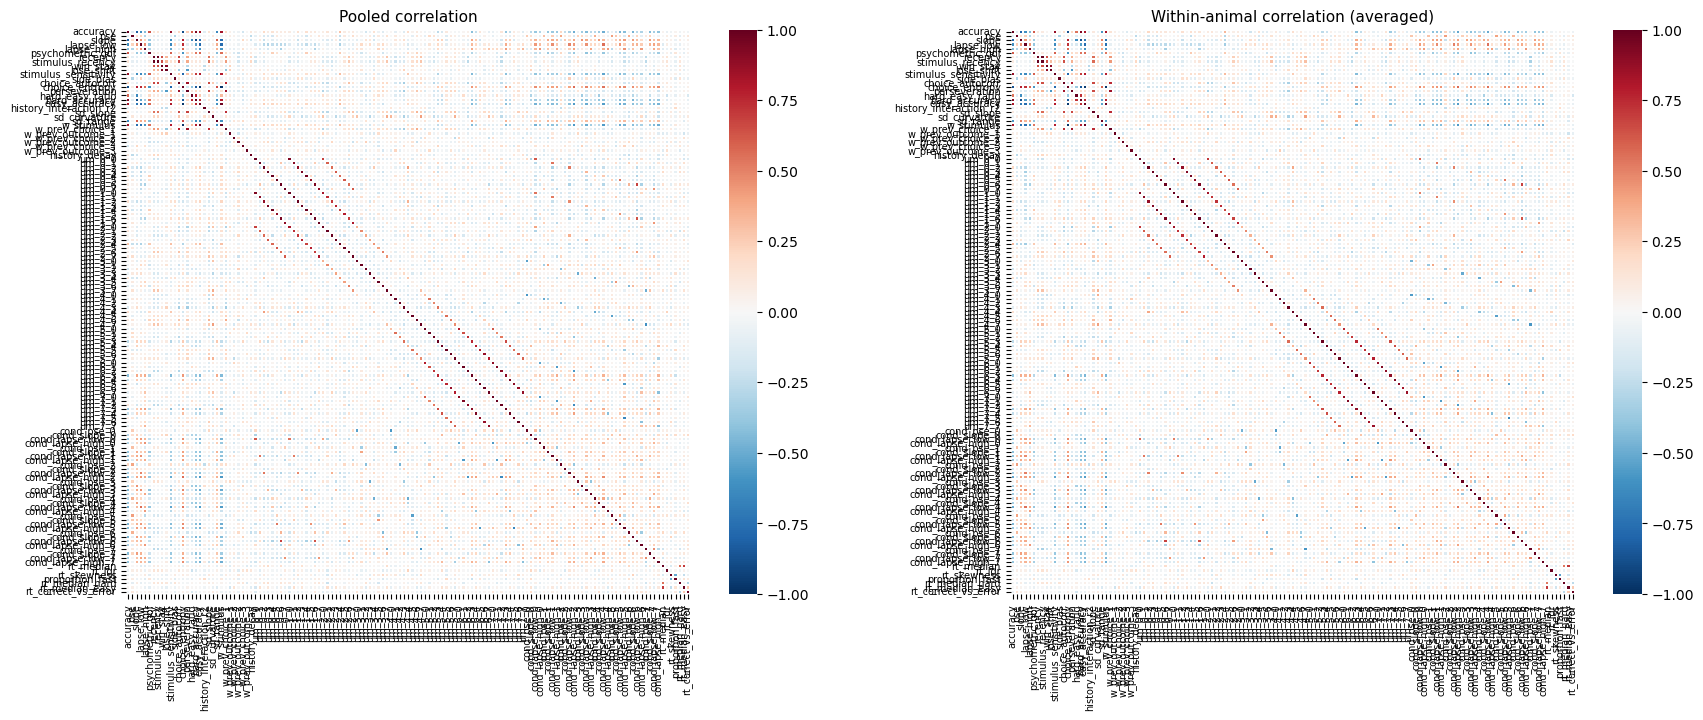

In [12]:
MIN_SESSIONS = 8

animal_ids = pooled_df['animal_id'].unique()
corr_within_all = []

for aid in animal_ids:
    adf = pooled_df[pooled_df['animal_id'] == aid][clean_features]
    if len(adf) < MIN_SESSIONS:
        continue
    corr_a = adf.corr(method='spearman')
    if not corr_a.isnull().all().all():
        corr_within_all.append(corr_a.values)

if corr_within_all:
    corr_within_mean = np.nanmean(corr_within_all, axis=0)
    corr_within_df = pd.DataFrame(corr_within_mean,
                                   index=clean_features, columns=clean_features)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[0], square=True, linewidths=0.3,
                xticklabels=True, yticklabels=True)
    axes[0].set_title('Pooled correlation', fontsize=11)
    axes[0].tick_params(labelsize=7)

    sns.heatmap(corr_within_df, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[1], square=True, linewidths=0.3,
                xticklabels=True, yticklabels=True)
    axes[1].set_title('Within-animal correlation (averaged)', fontsize=11)
    axes[1].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough animals with sufficient sessions for within-animal correlation.")

### 5.1 Within-Animal Correlation with Session Index

Which features consistently track learning (monotonic change with session number)?
Spearman ρ(feature, session_index) computed per animal, then summarised.

Spearman ρ(feature, session_index) — averaged across animals:
               feature  mean_rho  median_rho  std_rho  n_animals  frac_positive  frac_negative
            w_stimulus     0.920       0.930    0.041          5            1.0            0.0
        choice_entropy    -0.905      -0.940    0.061          5            0.0            1.0
         easy_accuracy     0.903       0.918    0.041          5            1.0            0.0
                 slope    -0.815      -0.866    0.110          5            0.0            1.0
         hard_accuracy     0.802       0.849    0.110          5            1.0            0.0
              accuracy     0.788       0.813    0.106          5            1.0            0.0
  stimulus_sensitivity     0.680       0.693    0.101          5            1.0            0.0
             lapse_low    -0.676      -0.764    0.159          5            0.0            1.0
              sd_range    -0.600      -0.629    0.114          5            0.0    

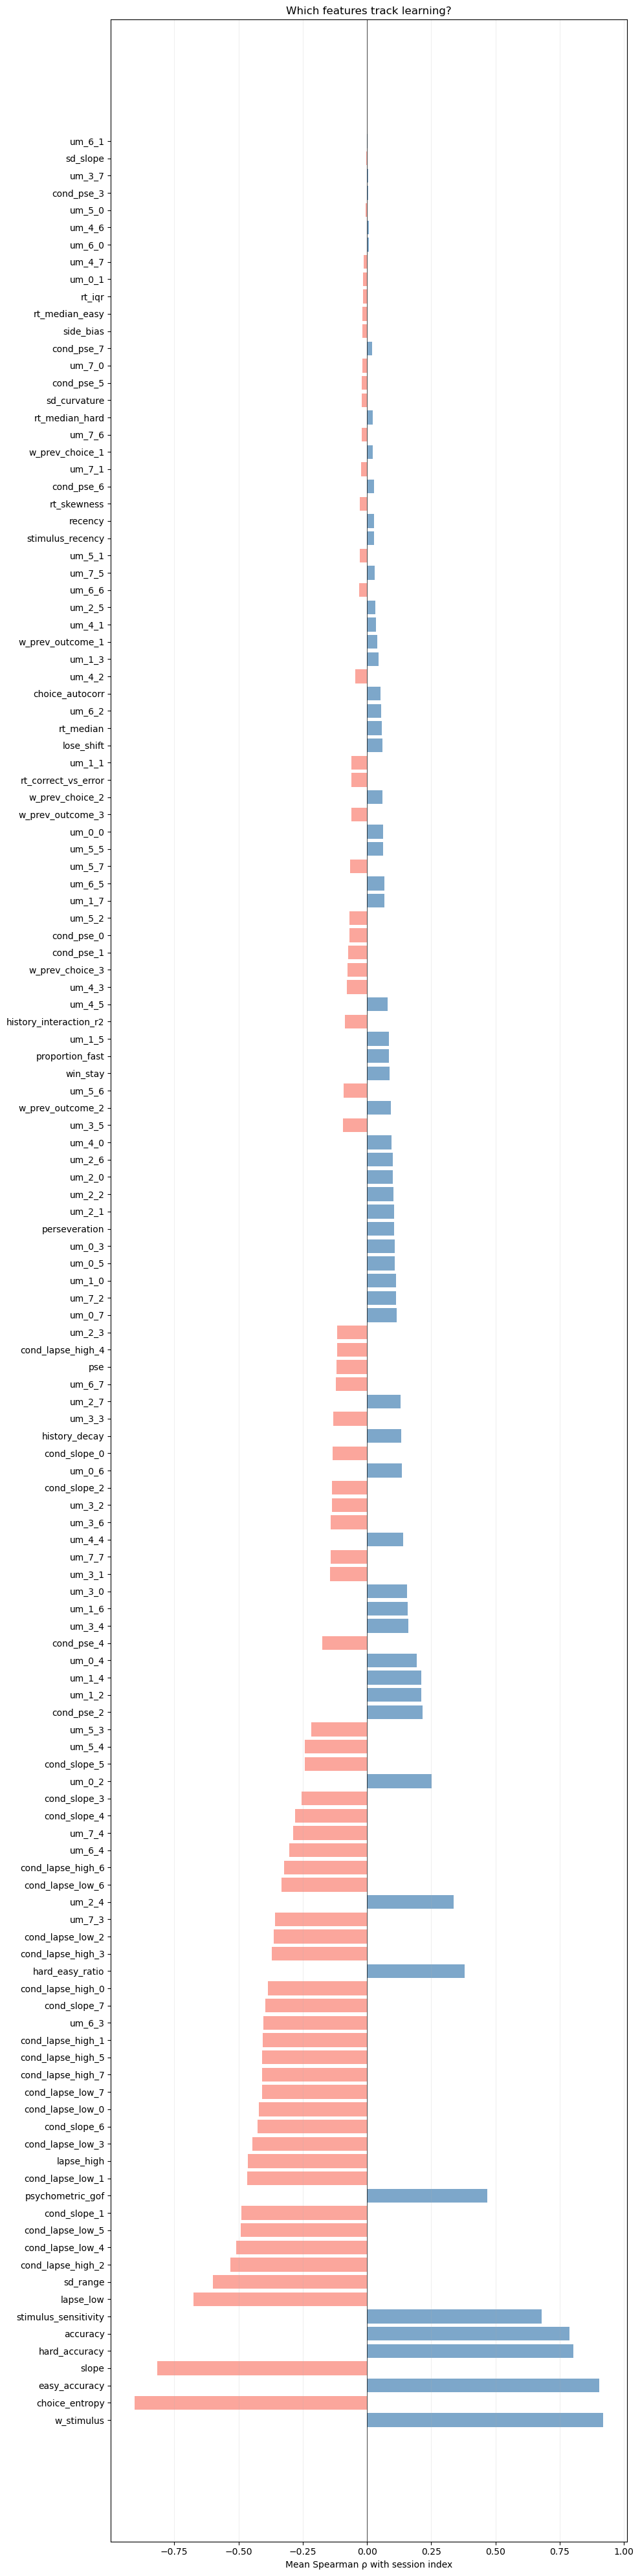

In [13]:
rho_results = {feat: [] for feat in clean_features}

for aid in animal_ids:
    adf = pooled_df[pooled_df['animal_id'] == aid].sort_values('session_idx')
    if len(adf) < MIN_SESSIONS:
        continue

    sess_idx = adf['session_idx'].values

    for feat in clean_features:
        vals = adf[feat].values.astype(float)
        valid = ~np.isnan(vals)
        if valid.sum() < MIN_SESSIONS:
            continue
        rho, p = spearmanr(sess_idx[valid], vals[valid])
        rho_results[feat].append(rho)

# Summarise
rows = []
for feat in clean_features:
    rhos = rho_results[feat]
    if len(rhos) < 3:
        continue
    arr = np.array(rhos)
    rows.append({
        'feature': feat,
        'mean_rho': np.mean(arr),
        'median_rho': np.median(arr),
        'std_rho': np.std(arr),
        'n_animals': len(arr),
        'frac_positive': np.mean(arr > 0),
        'frac_negative': np.mean(arr < 0),
    })

rho_df = pd.DataFrame(rows).sort_values('mean_rho', key=abs, ascending=False)

print("Spearman ρ(feature, session_index) — averaged across animals:")
print(rho_df.round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, len(rho_df) * 0.3)))
colours = ['steelblue' if r > 0 else 'salmon' for r in rho_df['mean_rho']]
ax.barh(rho_df['feature'], rho_df['mean_rho'], color=colours, alpha=0.7)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Mean Spearman ρ with session index')
ax.set_title('Which features track learning?')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

---
## 6. PCA — Effective Dimensionality

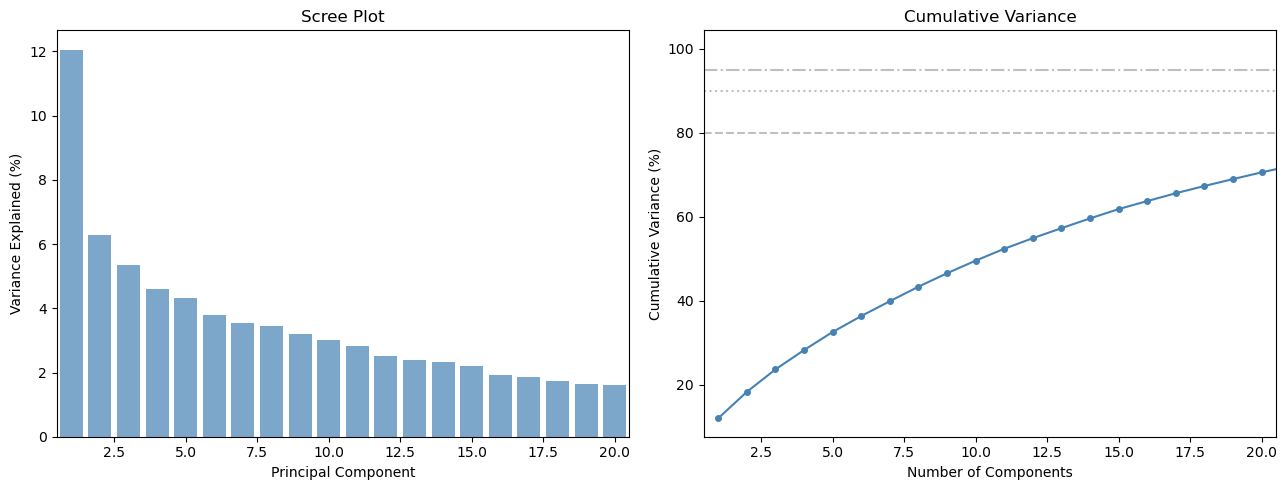

80% variance → 28 components
85% variance → 33 components
90% variance → 40 components
95% variance → 51 components


In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(corr_df)
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained * 100, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0.5, min(20.5, len(explained) + 0.5))

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, 'o-',
             color='steelblue', markersize=4)
for thresh, style in [(0.80, '--'), (0.90, ':'), (0.95, '-.')]:
    axes[1].axhline(thresh * 100, color='grey', linestyle=style, alpha=0.5)
    n_comp = np.argmax(cumulative >= thresh) + 1
    axes[1].annotate(f'{thresh*100:.0f}%: {n_comp} PCs',
                     xy=(n_comp + 0.3, thresh * 100 - 2), fontsize=8)

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance')
axes[1].set_xlim(0.5, min(20.5, len(cumulative) + 0.5))

plt.tight_layout()
plt.show()

for thresh in [0.80, 0.85, 0.90, 0.95]:
    n_comp = np.argmax(cumulative >= thresh) + 1
    print(f"{thresh*100:.0f}% variance → {n_comp} components")

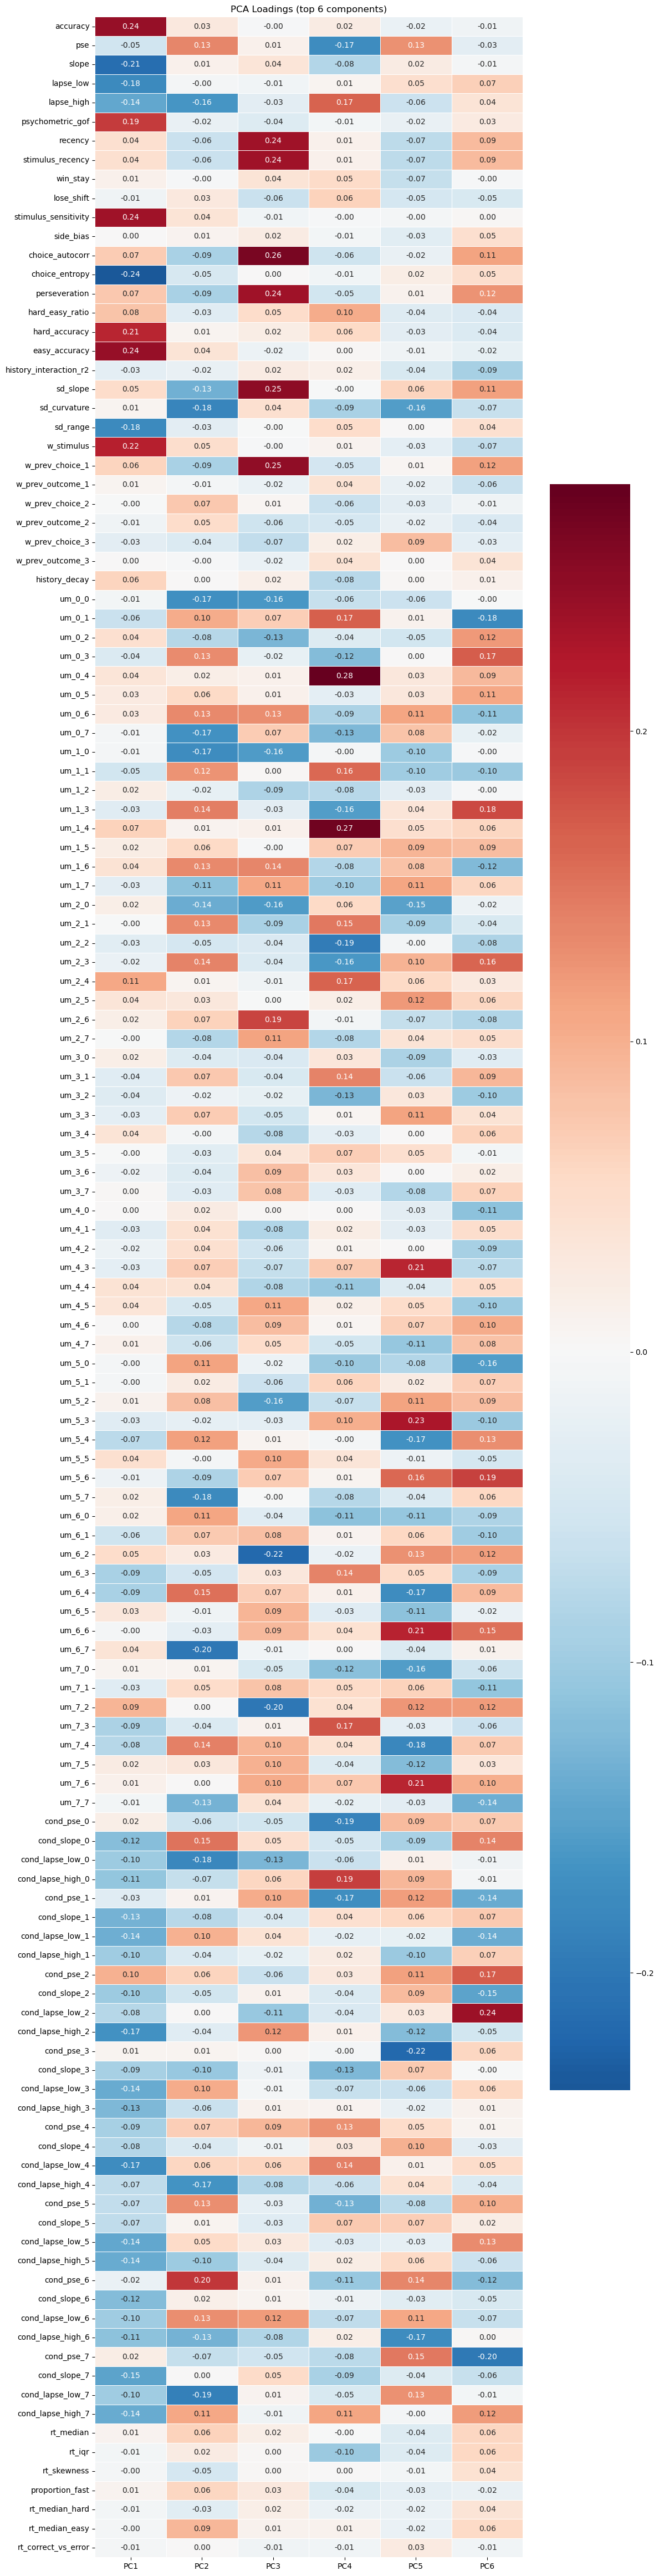

Top 3 features per component:

PC1 (12.1% var):
  + easy_accuracy: 0.242
  + accuracy: 0.242
  - choice_entropy: 0.238

PC2 (6.3% var):
  + cond_pse_6: 0.201
  - um_6_7: 0.200
  - cond_lapse_low_7: 0.190

PC3 (5.3% var):
  + choice_autocorr: 0.265
  + sd_slope: 0.248
  + w_prev_choice_1: 0.247

PC4 (4.6% var):
  + um_0_4: 0.280
  + um_1_4: 0.271
  - um_2_2: 0.195



In [15]:
# Loadings
n_show = min(6, len(explained))
loadings = pd.DataFrame(pca.components_[:n_show].T,
                         index=clean_features,
                         columns=[f'PC{i+1}' for i in range(n_show)])

fig, ax = plt.subplots(figsize=(12, max(6, len(clean_features) * 0.35)))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            ax=ax, linewidths=0.5)
ax.set_title(f'PCA Loadings (top {n_show} components)')
plt.tight_layout()
plt.show()

print("Top 3 features per component:\n")
for pc_idx in range(min(4, n_show)):
    pc = f'PC{pc_idx + 1}'
    abs_l = loadings[pc].abs().sort_values(ascending=False)
    print(f"{pc} ({explained[pc_idx]*100:.1f}% var):")
    for feat, val in abs_l.head(3).items():
        sign = '+' if loadings.loc[feat, pc] > 0 else '-'
        print(f"  {sign} {feat}: {val:.3f}")
    print()

---
## 7. Early vs Late Validation (Wilcoxon)

Which features significantly change between early (first N sessions) and late
(last N sessions) within each animal? This is a paired within-animal test — the
most direct evidence that a feature carries learning-phase information.

In [16]:
N_WINDOW = 5

early_late_results = []

for feat in clean_features:
    early_vals = []
    late_vals = []

    for aid in animal_ids:
        adf = pooled_df[pooled_df['animal_id'] == aid].sort_values('session_idx')
        if len(adf) < 2 * N_WINDOW:
            continue

        early = adf[feat].iloc[:N_WINDOW].mean()
        late = adf[feat].iloc[-N_WINDOW:].mean()

        if np.isnan(early) or np.isnan(late):
            continue

        early_vals.append(early)
        late_vals.append(late)

    if len(early_vals) < 5:
        continue

    early_arr = np.array(early_vals)
    late_arr = np.array(late_vals)

    try:
        stat, p = wilcoxon(early_arr, late_arr)
    except ValueError:
        stat, p = np.nan, np.nan

    early_late_results.append({
        'feature': feat,
        'early_mean': np.mean(early_arr),
        'late_mean': np.mean(late_arr),
        'delta': np.mean(late_arr) - np.mean(early_arr),
        'wilcoxon_stat': stat,
        'wilcoxon_p': p,
        'n_animals': len(early_vals),
    })

el_df = pd.DataFrame(early_late_results).sort_values('wilcoxon_p')
print(f"Early (first {N_WINDOW}) vs Late (last {N_WINDOW}) — paired Wilcoxon:")
print(el_df.round(4).to_string(index=False))

Early (first 5) vs Late (last 5) — paired Wilcoxon:
               feature  early_mean  late_mean   delta  wilcoxon_stat  wilcoxon_p  n_animals
              accuracy      0.7344     0.8990  0.1646            0.0      0.0625          5
              sd_range      0.3001     0.1264 -0.1737            0.0      0.0625          5
            w_stimulus      2.2179     8.2779  6.0600            0.0      0.0625          5
     cond_lapse_high_5      0.1324     0.0246 -0.1077            0.0      0.0625          5
      cond_lapse_low_5      0.1416     0.0064 -0.1352            0.0      0.0625          5
          cond_slope_5      0.2732     0.0969 -0.1763            0.0      0.0625          5
      cond_lapse_low_1      0.1031     0.0080 -0.0951            0.0      0.0625          5
                um_2_4     -0.0791     0.0054  0.0845            0.0      0.0625          5
      cond_lapse_low_4      0.1588     0.0176 -0.1412            0.0      0.0625          5
          cond_slope_4      

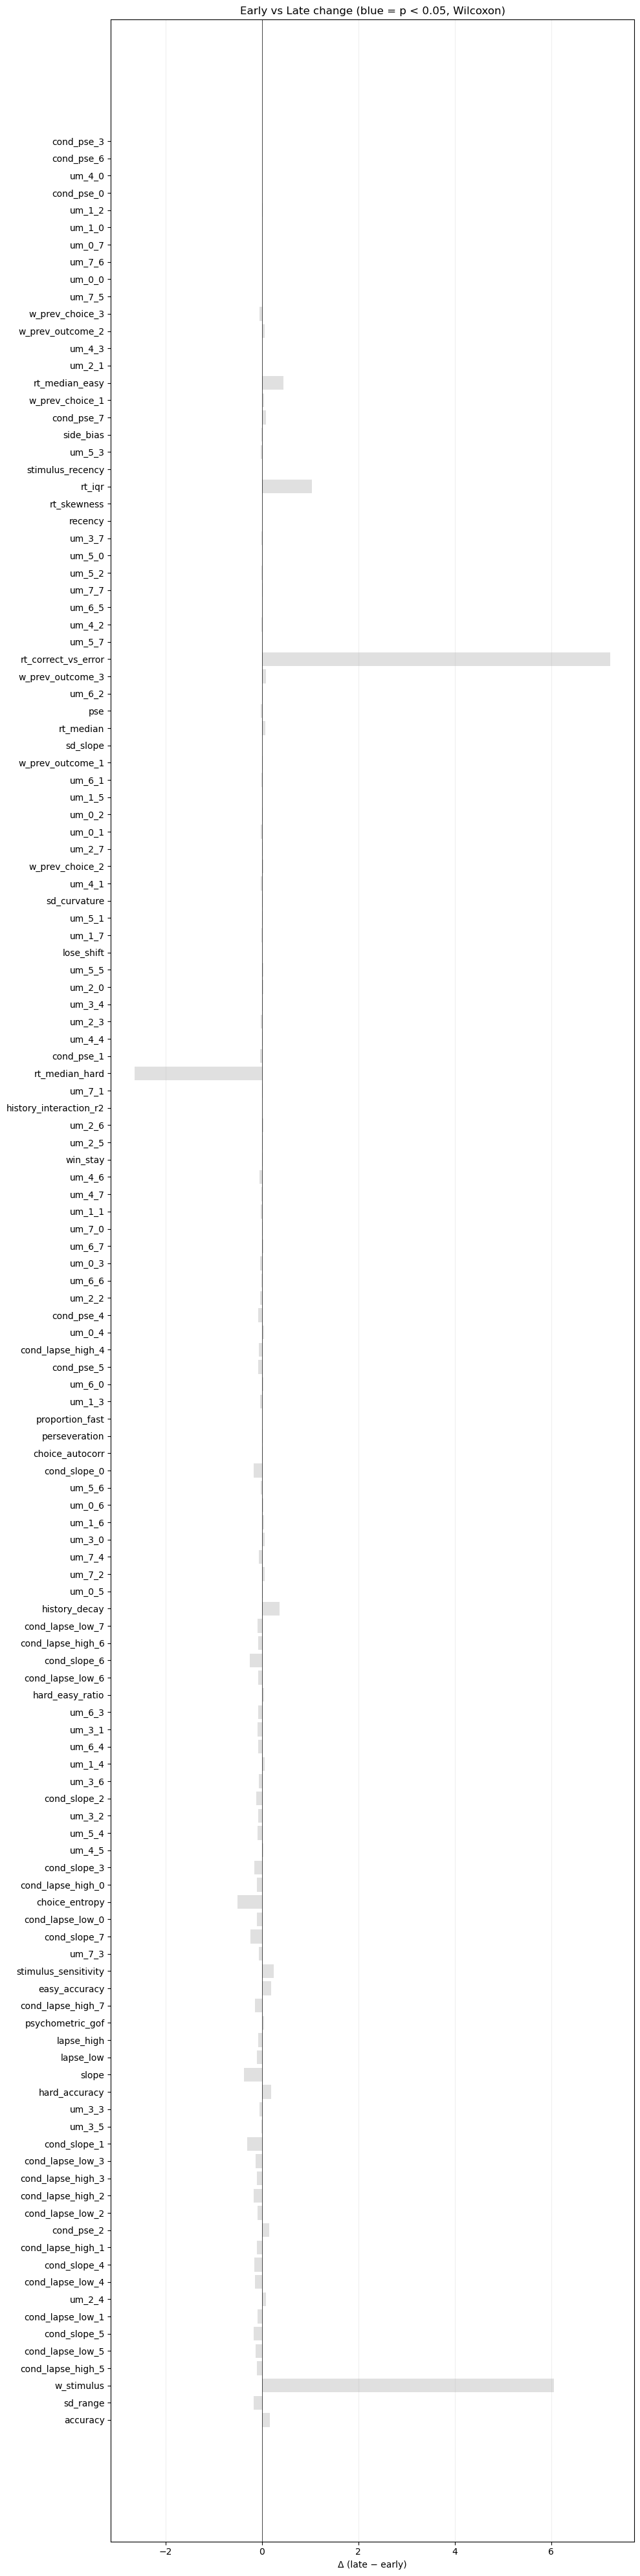


0 / 133 features significantly change early → late (p < 0.05)


In [17]:
# Visualise: effect sizes
sig = el_df[el_df['wilcoxon_p'] < 0.05].copy()
nonsig = el_df[el_df['wilcoxon_p'] >= 0.05].copy()

fig, ax = plt.subplots(figsize=(10, max(4, len(el_df) * 0.3)))

# Plot all features
for _, row in el_df.iterrows():
    colour = 'steelblue' if row['wilcoxon_p'] < 0.05 else 'lightgrey'
    ax.barh(row['feature'], row['delta'], color=colour, alpha=0.7)

ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Δ (late − early)')
ax.set_title(f'Early vs Late change (blue = p < 0.05, Wilcoxon)')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

n_sig = len(sig)
print(f"\n{n_sig} / {len(el_df)} features significantly change early → late (p < 0.05)")

---
## 8. Feature Selection: Recommendations

### Criteria:
1. **One per correlated cluster** — most interpretable representative
2. **Covers top PC loadings** — spans main variance axes
3. **Significant early→late change** — carries learning-phase information
4. **Proposal-relevant** — distinguishes model-updating from inference
5. **Low NaN rate**

### Suggested core set:

| Feature | Rationale |
|---------|-----------|
| `accuracy` | Overall performance |
| `pse` | Boundary estimate / adaptation |
| `slope` | Discrimination quality |
| `recency` | Category-based serial dependence |
| `choice_entropy` | Choice variability |
| `win_stay` | Reward sensitivity |
| `side_bias` | Motor bias (confound) |
| `lapse_low` | Attentional engagement |

### Likely exclusions:
- `hard_accuracy`, `easy_accuracy` → redundant with `accuracy` + `slope`
- `stimulus_recency` → correlated with `recency` under uniform
- `recency_divergence` → near-zero pre-shift
- `sd_*` → expensive and noisy
- Binned stats → high-dimensional

In [18]:
SELECTED_FEATURES = [
    'accuracy', 'pse', 'slope', 'recency',
    'choice_entropy', 'win_stay', 'side_bias', 'lapse_low',
]

available = [f for f in SELECTED_FEATURES if f in clean_features]
missing = [f for f in SELECTED_FEATURES if f not in clean_features]

print(f"Selected features ({len(available)} available):")
for f in available:
    # Annotate with cluster and early-late p-value
    cl = cluster_df[cluster_df['feature'] == f]['cluster'].values
    cl_str = f"cluster {cl[0]}" if len(cl) > 0 else "?"
    el_row = el_df[el_df['feature'] == f]
    p_str = f"p={el_row['wilcoxon_p'].values[0]:.4f}" if len(el_row) > 0 else "?"
    print(f"  ✓ {f:<20} ({cl_str}, early-late {p_str})")

if missing:
    print(f"\nNot in data: {missing}")

Selected features (8 available):
  ✓ accuracy             (cluster 84, early-late p=0.0625)
  ✓ pse                  (cluster 11, early-late p=0.8125)
  ✓ slope                (cluster 84, early-late p=0.0625)
  ✓ recency              (cluster 36, early-late p=1.0000)
  ✓ choice_entropy       (cluster 84, early-late p=0.0625)
  ✓ win_stay             (cluster 35, early-late p=0.4375)
  ✓ side_bias            (cluster 12, early-late p=1.0000)
  ✓ lapse_low            (cluster 85, early-late p=0.0625)


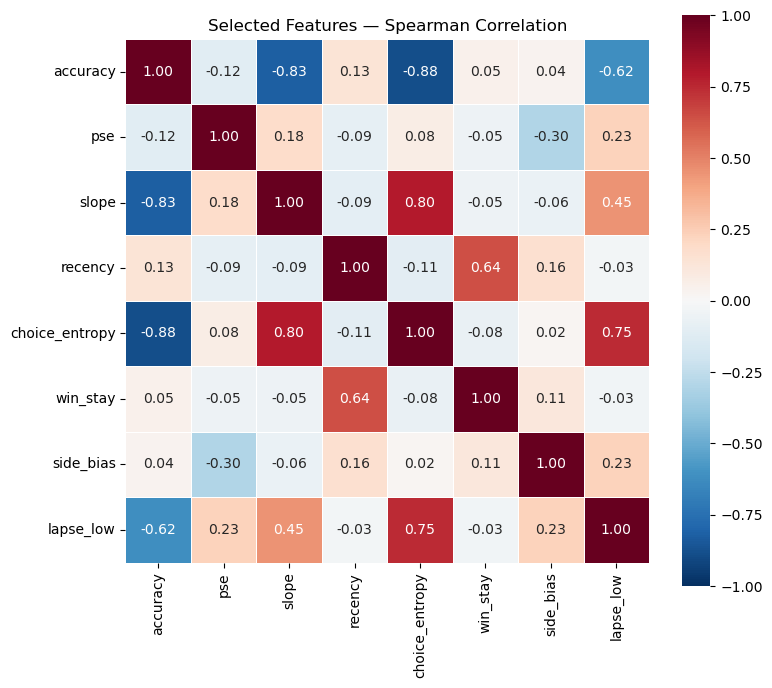

⚠ High correlation: accuracy ↔ slope: ρ = -0.83
⚠ High correlation: accuracy ↔ choice_entropy: ρ = -0.88
⚠ High correlation: slope ↔ choice_entropy: ρ = 0.80
⚠ High correlation: choice_entropy ↔ lapse_low: ρ = 0.75


In [19]:
# Correlation among selected features — check for residual redundancy
if len(available) >= 2:
    selected_corr = corr_df[available].corr(method='spearman')

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(selected_corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', ax=ax, square=True, linewidths=0.5)
    ax.set_title('Selected Features — Spearman Correlation')
    plt.tight_layout()
    plt.show()

    flagged = False
    for i in range(len(available)):
        for j in range(i+1, len(available)):
            rho = selected_corr.iloc[i, j]
            if abs(rho) > 0.70:
                print(f"⚠ High correlation: {available[i]} ↔ {available[j]}: ρ = {rho:.2f}")
                flagged = True
    if not flagged:
        print("No high correlations (|ρ| > 0.70) among selected features.")

---
## 9. Export & Next Steps

**Next:**
1. Run on real data — cluster structure and PCA will shift
2. Revisit after post-manipulation data exists
3. Feed `SELECTED_FEATURES` into further (SLDS) fitting
4. Iterate if the further analysis recovery is poor